In [25]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
pipe = Pipeline([
    
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [27]:
# Parameter grid
param_grid = [

    # Logistic Regression
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [SVC(probability=True, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [DecisionTreeClassifier(class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM (does not use class_weight, uses scale_pos_weight instead)
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]]  # balance positive class
    }
]

In [31]:
# GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [5, 10, 15]},
                         {...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [32]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1357
           1       0.48      0.75      0.59       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.70      1804
weighted avg       0.80      0.74      0.76      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection', SelectKBest(k=5)),
                ('classifier',
                 SVC(C=0.1, class_weight='balanced', probability=True))])

Best Parameters:
{'classifier': SVC(class_weight='balanced', probability=True), 'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'feature_selection__k': 5}


In [33]:
# Choose the sampler:
# Option 1: oversample the minority class
sampler = RandomOverSampler(random_state=42)

# Option 2: undersample the majority class
# sampler = RandomUnderSampler(random_state=42)

# Option 3:
# sampler =SMOTE(random_state=42)

# Pipeline with over/under-sampling and SelectKBest
pipe2 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])



In [35]:
grid = GridSearchCV(
    pipe2,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [5, 10, 15]},
                         {...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [36]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1357
           1       0.47      0.74      0.58       447

    accuracy                           0.73      1804
   macro avg       0.68      0.74      0.69      1804
weighted avg       0.79      0.73      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 SVC(C=10, class_weight='balanced', kernel='linear',
                     probability=True))])

Best Parameters:
{'classifier': SVC(class_weight='balanced', probability=True), 'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'feature_selection__k': 10}


In [38]:
sampler =SMOTE(random_state=42)

pipe3 = Pipeline([

    ('scaler', MinMaxScaler()),
    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [39]:
grid = GridSearchCV(
    pipe3,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('sampler', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [40]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1357
           1       0.48      0.73      0.58       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.69      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()), ('sampler', SMOTE(random_state=42)),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

Best Parameters:
{'classifier': LogisticRegression(class_weight='balanced', max_iter=1000), 'classifier__C': 1, 'classifier__solver': 'liblinear', 'feature_selection__k': 10}


In [41]:
## SMOTE

In [49]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [50]:
pipe4 = Pipeline([

    ('scaler', MinMaxScaler()),
    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [51]:
grid = GridSearchCV(
    pipe4,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('sampler', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [...
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__min_samples_leaf': [1, 2, 4],
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [54]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1357
           1       0.48      0.73      0.58       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.69      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()), ('sampler', SMOTE(random_state=42)),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 LogisticRegression(C=1, max_iter=1000, solver='liblinear'))])

Best Parameters:
{'classifier': LogisticRegression(max_iter=1000), 'classifier__C': 1, 'classifier__solver': 'liblinear', 'feature_selection__k': 10}


In [ ]:
## try select from model 

In [55]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'], 
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [56]:
pipe5 = Pipeline([

    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', 
 SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [57]:
grid = GridSearchCV(
    pipe5,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__s...
                          'classifier__min_samples_leaf': [1, 2, 4],
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring='f1', verbose=2)

In [58]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1357
           1       0.48      0.70      0.57       447

    accuracy                           0.74      1804
   macro avg       0.68      0.73      0.69      1804
weighted avg       0.78      0.74      0.75      1804

Best Model:
Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=4,
                                        random_state=42))])

Best Parameters:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_

In [59]:
# let's try f1 score for class 1

In [63]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'], 
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [65]:
pipe6 = Pipeline([

    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', 
 SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [60]:
from sklearn.metrics import make_scorer, f1_score

In [67]:
f1_class1 = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(
    pipe6,
    param_grid,
    cv=3,
    scoring=f1_class1,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__s...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=2)

In [68]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1357
           1       0.48      0.70      0.57       447

    accuracy                           0.74      1804
   macro avg       0.68      0.73      0.69      1804
weighted avg       0.78      0.74      0.75      1804

Best Model:
Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=4,
                                        random_state=42))])

Best Parameters:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_

In [ ]:
### Add more models for class 1

In [71]:
pipe7 = Pipeline([
    
    ('scaler', MinMaxScaler()),
    ('feature_selection',SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [72]:
# Parameter grid
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
       'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier(class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM (does not use class_weight, uses scale_pos_weight instead)
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]]  # balance positive class
    }
]

In [73]:


f1_class1 = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(
    pipe7,
    param_grid,
    cv=3,
    scoring=f1_class1,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10]...
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=2)

In [74]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1357
           1       0.48      0.74      0.59       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.70      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])

Best Parameters:
{'classifier': LogisticRegression(class_weight='balanced', max_iter=1000), 'classifier__C': 0

In [83]:
best_model = grid.best_estimator_

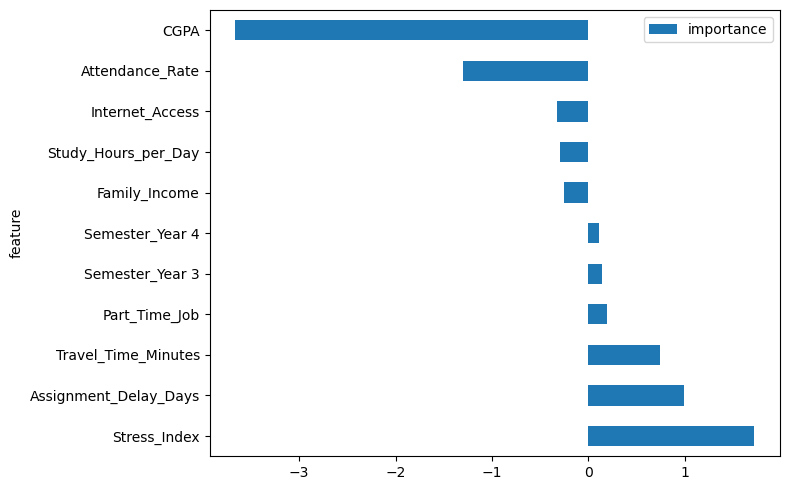

In [86]:
best_pipe = grid.best_estimator_

selector = best_pipe.named_steps['feature_selection']
classifier = best_pipe.named_steps['classifier']

selected_features = X_train.columns[selector.get_support()]

# LogisticRegression → coef_
if hasattr(classifier, 'coef_'):
    importance = classifier.coef_[0]
elif hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_

feat_imp = pd.DataFrame({'feature': selected_features, 'importance': importance})
feat_imp = feat_imp.sort_values('importance', ascending=False)

feat_imp.plot(kind='barh', x='feature', y='importance', figsize=(8,5))
plt.tight_layout()
plt.show()